In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# 1. Represent the warehouse as a weighted graph
G_warehouse = nx.DiGraph()

# 2. Store the coordinates of all locations
warehouse_nodes = {
    'Receiving_Area': (0, 0),
    'Storage_A': (2, 1),
    'Storage_B': (1, 4),
    'Sorting_Area': (4, 2),
    'Inspection_Area': (5, 5),
    'Packing_Station': (7, 6)
}

edges = [
    ('Receiving_Area', 'Storage_B', 4.1),
    ('Receiving_Area', 'Storage_A', 2.2),
    ('Storage_B', 'Inspection_Area', 5.0),
    ('Storage_B', 'Sorting_Area', 6.0),
    ('Storage_A', 'Sorting_Area', 2.2),
    ('Sorting_Area', 'Inspection_Area', 3.2),
    ('Sorting_Area', 'Packing_Station', 5.0),
    ('Inspection_Area', 'Packing_Station', 2.2)
]
G_warehouse.add_weighted_edges_from(edges)

# 3. Implement a heuristic function h(n) using the Euclidean distance
def get_euclidean_distance(node1, node2, nodes_dict):
    x1, y1 = nodes_dict[node1]
    x2, y2 = nodes_dict[node2]
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# 4. Calculate and display the heuristic value for each location
goal_node = 'Packing_Station'
print("--- Heuristic Values h(n) ---")
h_values = {}
for node in warehouse_nodes:
    h_values[node] = get_euclidean_distance(node, goal_node, warehouse_nodes)
    print(f"{node}: {h_values[node]:.2f}")

# 6. Verify the heuristic condition: h(n) <= cost(n,m) + h(m)
print("\n--- Verifying Heuristic Consistency ---")
for u, v, data in G_warehouse.edges(data=True):
    cost = data['weight']
    is_consistent = h_values[u] <= cost + h_values[v]
    print(f"{u} -> {v} (Cost: {cost}): h({u})={h_values[u]:.2f} <= {cost} + h({v})={h_values[v]:.2f} -> {is_consistent}")

--- Heuristic Values h(n) ---
Receiving_Area: 9.22
Storage_A: 7.07
Storage_B: 6.32
Sorting_Area: 5.00
Inspection_Area: 2.24
Packing_Station: 0.00

--- Verifying Heuristic Consistency ---
Receiving_Area -> Storage_B (Cost: 4.1): h(Receiving_Area)=9.22 <= 4.1 + h(Storage_B)=6.32 -> True
Receiving_Area -> Storage_A (Cost: 2.2): h(Receiving_Area)=9.22 <= 2.2 + h(Storage_A)=7.07 -> True
Storage_B -> Inspection_Area (Cost: 5.0): h(Storage_B)=6.32 <= 5.0 + h(Inspection_Area)=2.24 -> True
Storage_B -> Sorting_Area (Cost: 6.0): h(Storage_B)=6.32 <= 6.0 + h(Sorting_Area)=5.00 -> True
Storage_A -> Sorting_Area (Cost: 2.2): h(Storage_A)=7.07 <= 2.2 + h(Sorting_Area)=5.00 -> True
Inspection_Area -> Packing_Station (Cost: 2.2): h(Inspection_Area)=2.24 <= 2.2 + h(Packing_Station)=0.00 -> False
Sorting_Area -> Inspection_Area (Cost: 3.2): h(Sorting_Area)=5.00 <= 3.2 + h(Inspection_Area)=2.24 -> True
Sorting_Area -> Packing_Station (Cost: 5.0): h(Sorting_Area)=5.00 <= 5.0 + h(Packing_Station)=0.00 -> T

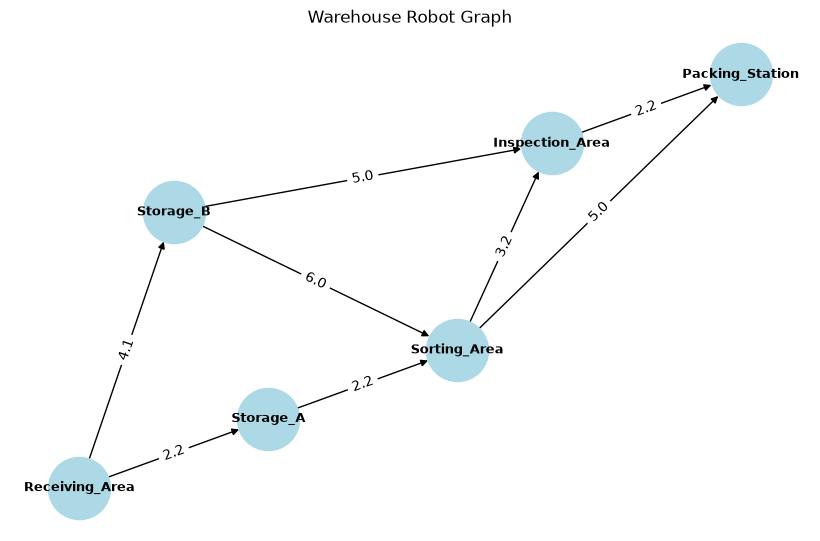

Explanation: Euclidean distance is suitable because it represents the shortest possible geometric path between two physical locations. In physical pathfinding, a straight line never overestimates the actual cost required, making it an admissible and consistent heuristic.


In [2]:
# NetworkX visualization of the warehouse graph[cite: 1]
plt.figure(figsize=(8, 5))
nx.draw(G_warehouse, warehouse_nodes, with_labels=True, node_color='lightblue', node_size=2000, font_size=9, font_weight='bold')
labels = nx.get_edge_attributes(G_warehouse, 'weight')
nx.draw_networkx_edge_labels(G_warehouse, warehouse_nodes, edge_labels=labels)
plt.title("Warehouse Robot Graph")
plt.show()

# 5. Explain why Euclidean distance is a suitable heuristic[cite: 1]
print("Explanation: Euclidean distance is suitable because it represents the shortest possible geometric path between two physical locations. In physical pathfinding, a straight line never overestimates the actual cost required, making it an admissible and consistent heuristic.")

In [3]:
import heapq

# 1. Represent the airport layout as a weighted graph[cite: 1]
G_airport = nx.DiGraph()
airport_nodes = {
    'Baggage_Area': (0, 0),
    'Security': (2, 1),
    'Checkpoint': (1, 4),
    'Food_Court': (4, 2),
    'Terminal_Hall': (5, 5),
    'Departure_Gate': (8, 6)
}

airport_edges = [
    ('Baggage_Area', 'Checkpoint', 4.1),
    ('Baggage_Area', 'Security', 2.2),
    ('Checkpoint', 'Terminal_Hall', 5.0),
    ('Security', 'Food_Court', 2.2),
    ('Food_Court', 'Terminal_Hall', 3.2),
    ('Food_Court', 'Departure_Gate', 6.0),
    ('Terminal_Hall', 'Departure_Gate', 3.2)
]
G_airport.add_weighted_edges_from(airport_edges)

# 2. Use Euclidean distance to the Departure Gate as the heuristic[cite: 1]
def h(node):
    return get_euclidean_distance(node, 'Departure_Gate', airport_nodes)

# 3. Implement Greedy Best-First Search (GBFS) using f(n) = h(n)[cite: 1]
def gbfs(graph, start, goal):
    priority_queue = []
    heapq.heappush(priority_queue, (h(start), start))
    came_from = {start: None}
    expanded_nodes = [] # 5. Record the order in which nodes are expanded[cite: 1]
    
    while priority_queue:
        _, current = heapq.heappop(priority_queue)
        expanded_nodes.append(current)
        
        if current == goal:
            break
            
        for neighbor in graph.neighbors(current):
            if neighbor not in came_from:
                came_from[neighbor] = current
                heapq.heappush(priority_queue, (h(neighbor), neighbor))
                
    # Reconstruct path
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = came_from.get(curr)
    path.reverse()
    
    return path, expanded_nodes

# 4. Set Start and Goal nodes[cite: 1]
start_node = 'Baggage_Area'
goal_node = 'Departure_Gate'

path, expanded = gbfs(G_airport, start_node, goal_node)

# 7. Calculate the actual total cost of the path found[cite: 1]
total_cost = sum(G_airport[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

print("Node Expansion Sequence:", expanded)
print("Solution Path:", path)
print(f"Total Path Cost: {total_cost:.2f}")

# 8. Explain why GBFS selected the nodes in that order[cite: 1]
print("\nExplanation: GBFS selected these nodes because it evaluates paths based entirely on the heuristic f(n) = h(n), blindly moving toward the node that seems closest to the goal geographically, ignoring the actual accumulated path cost.")

Node Expansion Sequence: ['Baggage_Area', 'Checkpoint', 'Terminal_Hall', 'Departure_Gate']
Solution Path: ['Baggage_Area', 'Checkpoint', 'Terminal_Hall', 'Departure_Gate']
Total Path Cost: 12.30

Explanation: GBFS selected these nodes because it evaluates paths based entirely on the heuristic f(n) = h(n), blindly moving toward the node that seems closest to the goal geographically, ignoring the actual accumulated path cost.


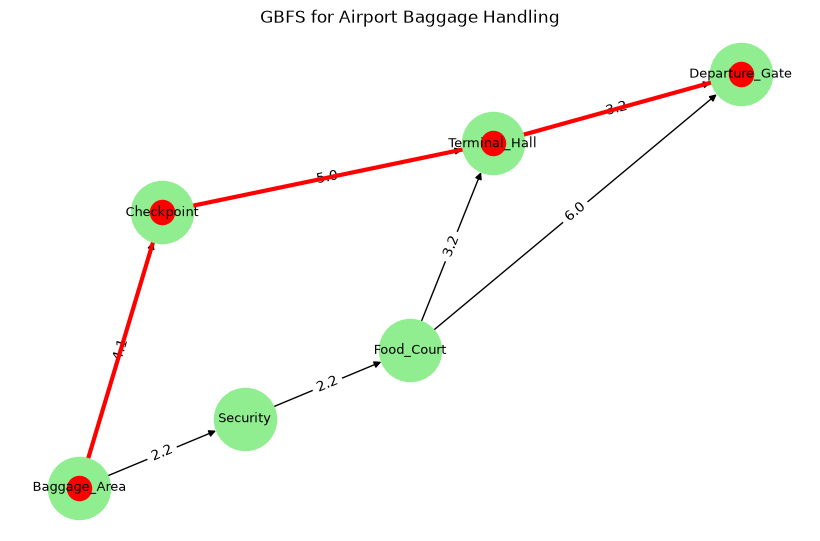

In [4]:
# Display the solution path found by GBFS[cite: 1]
plt.figure(figsize=(8, 5))
pos = airport_nodes

# Draw nodes and edges
nx.draw(G_airport, pos, with_labels=True, node_color='lightgreen', node_size=2000, font_size=9)
nx.draw_networkx_edge_labels(G_airport, pos, edge_labels=nx.get_edge_attributes(G_airport, 'weight'))

# Highlight the solution path[cite: 1]
path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G_airport, pos, edgelist=path_edges, edge_color='red', width=3)
nx.draw_networkx_nodes(G_airport, pos, nodelist=path, node_color='red')

plt.title("GBFS for Airport Baggage Handling")
plt.show()

In [7]:
import pandas as pd

# Drone layout representation
G_drone = nx.DiGraph()
drone_nodes = {
    'Distribution_Center': (0, 0),
    'Zone_A': (2, 1),
    'Zone_B': (1, 4),
    'Zone_C': (4, 2),
    'Zone_D': (5, 5),
    'Customer_Building': (8, 6)
}

drone_edges = [
    ('Distribution_Center', 'Zone_B', 3.0),
    ('Distribution_Center', 'Zone_A', 2.2),
    ('Zone_B', 'Zone_D', 5.0),
    ('Zone_A', 'Zone_C', 2.2),
    ('Zone_C', 'Zone_D', 3.2),
    ('Zone_C', 'Customer_Building', 6.0),
    ('Zone_D', 'Customer_Building', 3.2)
]
G_drone.add_weighted_edges_from(drone_edges)

# 2. Implement Weighted A* using f(n) = g(n) + w * h(n)[cite: 1]
def weighted_a_star(graph, start, goal, w, nodes_dict):
    priority_queue = []
    # 3. Use Euclidean distance as the heuristic[cite: 1]
    start_h = get_euclidean_distance(start, goal, nodes_dict)
    heapq.heappush(priority_queue, (0 + w * start_h, 0, start))
    
    came_from = {start: None}
    g_score = {start: 0}
    expanded_nodes = []
    
    while priority_queue:
        _, current_g, current = heapq.heappop(priority_queue)
        expanded_nodes.append(current)
        
        if current == goal:
            break
            
        for neighbor in graph.neighbors(current):
            tentative_g = g_score[current] + graph[current][neighbor]['weight']
            
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                h_score = get_euclidean_distance(neighbor, goal, nodes_dict)
                f_score = tentative_g + (w * h_score)
                heapq.heappush(priority_queue, (f_score, tentative_g, neighbor))
                
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = came_from.get(curr)
    path.reverse()
    
    return path, g_score[goal], len(expanded_nodes)

# 4. Run the search for w = 1, 1.5, 2, 3[cite: 1]
weights = [1.0, 1.5, 2.0, 3.0]
results = []

start_node = 'Distribution_Center'
goal_node = 'Customer_Building'

# 5. Record path, cost, and number of nodes expanded[cite: 1]
for w in weights:
    path, cost, expanded_count = weighted_a_star(G_drone, start_node, goal_node, w, drone_nodes)
    results.append({
        "Weight w": w,
        "Solution Path": " -> ".join(path),
        "Total Cost": cost,
        "Nodes Expanded": expanded_count
    })

# 6. Complete the following table[cite: 1]
df_results = pd.DataFrame(results)
display(df_results)

,Weight w,Solution Path,Total Cost,Nodes Expanded
0,1.0,Distribution_Center -> Zone_A -> Zone_C -> Cus...,10.4,5
1,1.5,Distribution_Center -> Zone_A -> Zone_C -> Cus...,10.4,4
2,2.0,Distribution_Center -> Zone_B -> Zone_D -> Cus...,11.2,4
3,3.0,Distribution_Center -> Zone_B -> Zone_D -> Cus...,11.2,4


In [10]:
# 7. Compare the results for different values of w[cite: 1]
print("--- Explanations ---")

# 8. Explain how increasing w changes the balance[cite: 1]
print("1. Balance change: Increasing w gives greater importance to the heuristic over the actual cost g(n). It forces the algorithm to trust the heuristic more than the actual cost, causing it to behave more like a greedy search[cite: 1].")

# 9. Explain why Weighted A* with w > 1 may return a higher-cost path[cite: 1]
print("2. Optimality loss: Weighted A* with w > 1 may return a higher-cost path because increasing w does not provide the same optimality guarantee as normal A*. While it can reduce the amount of search in some problems, it risks overestimating the optimal path and losing the guarantee of finding the absolute shortest path[cite: 1].")

--- Explanations ---
1. Balance change: Increasing w gives greater importance to the heuristic over the actual cost g(n). It forces the algorithm to trust the heuristic more than the actual cost, causing it to behave more like a greedy search[cite: 1].
2. Optimality loss: Weighted A* with w > 1 may return a higher-cost path because increasing w does not provide the same optimality guarantee as normal A*. While it can reduce the amount of search in some problems, it risks overestimating the optimal path and losing the guarantee of finding the absolute shortest path[cite: 1].
